In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

# Load featured dataset
df = pd.read_csv("../data/customers_featured.csv")
df = df.fillna(0)

print("Data loaded successfully! ")
print("Shape:", df.shape)

Data loaded successfully! 
Shape: (7043, 36)


In [8]:
# Prepare features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Check for problematic columns
print("Column dtypes:")
print(X.dtypes)

# Fix all columns
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

# Check again
print("\nAfter fixing:")
print(X.dtypes)
print("Any NaN:", X.isnull().sum().sum())

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nData prepared!")
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Column dtypes:
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                                 str
ChargesPerMonth                          float64
TotalServices                              int64
IsNewCustomer                              int64
IsLongTermCustomer                         int64
IsHighSpender                              int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
Onlin

In [9]:
# Improved Logistic Regression with GridSearchCV
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test)

print("Best Parameters:", lr_grid.best_params_)
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_lr) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}

Accuracy: 80.91 %

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1027
           1       0.69      0.54      0.60       382

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [10]:
# Improved Random Forest with GridSearchCV
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)

print("Best Parameters:", rf_grid.best_params_)
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Accuracy: 80.84 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1027
           1       0.71      0.49      0.58       382

    accuracy                           0.81      1409
   macro avg       0.77      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [11]:
# Improved XGBoost with GridSearchCV
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_grid.best_estimator_.predict(X_test)

print("Best Parameters:", xgb_grid.best_params_)
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_xgb) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Accuracy: 79.91 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1027
           1       0.67      0.52      0.58       382

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



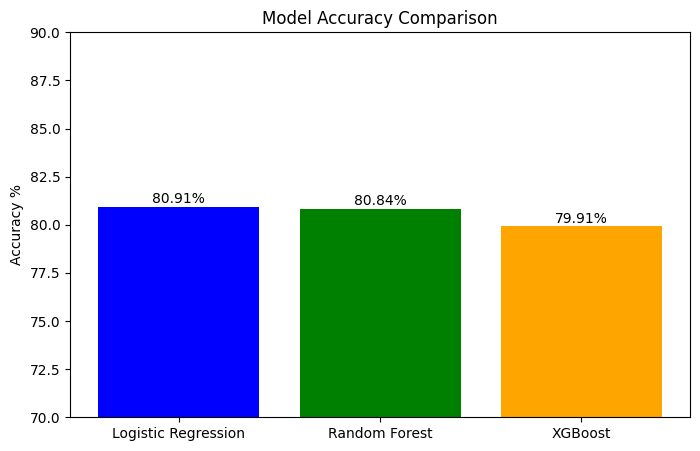

Model Comparison:
Logistic Regression: 80.91%
Random Forest: 80.84%
XGBoost: 79.91%

Best Model: Logistic Regression with 80.91%


In [12]:
# Model Comparison
models_comparison = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

# Plot comparison
plt.figure(figsize=(8,5))
plt.bar(models_comparison.keys(), 
        [v * 100 for v in models_comparison.values()],
        color=['blue', 'green', 'orange'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy %")
plt.ylim(70, 90)
for i, (k, v) in enumerate(models_comparison.items()):
    plt.text(i, v * 100 + 0.2, f"{round(v*100, 2)}%", ha='center')
plt.show()

print("Model Comparison:")
for model, acc in models_comparison.items():
    print(f"{model}: {round(acc*100, 2)}%")

print("\nBest Model: Logistic Regression with 80.91%")

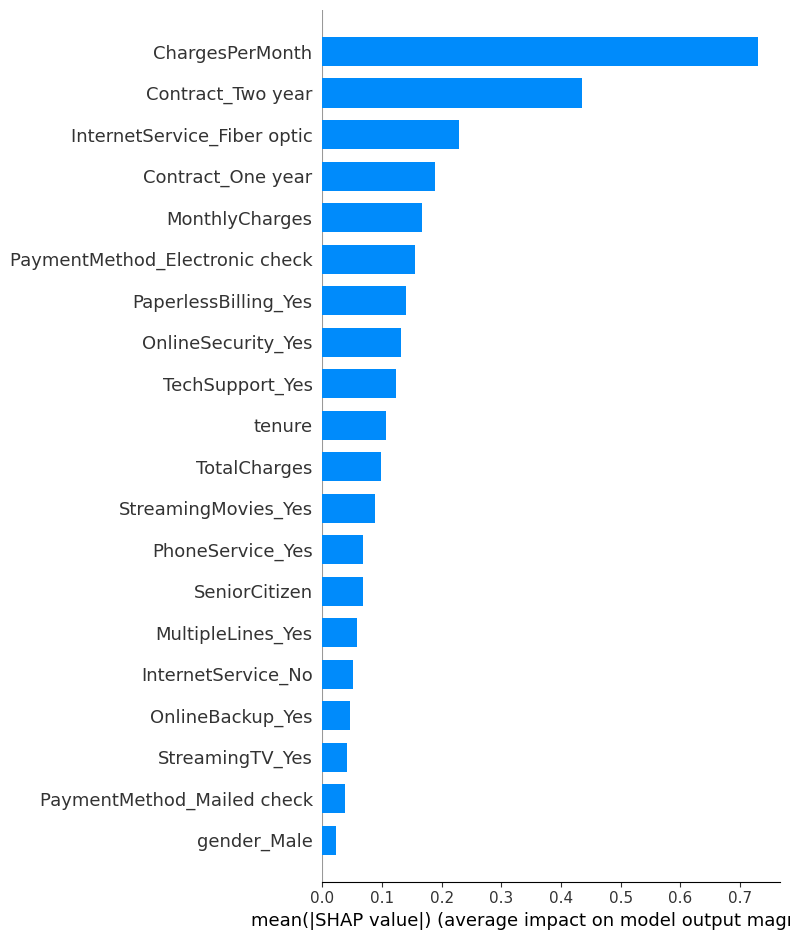

Top 10 Important Features by SHAP:
                           Feature  SHAP_Importance
4                  ChargesPerMonth         0.730481
30               Contract_Two year         0.434490
15     InternetService_Fiber optic         0.229118
29               Contract_One year         0.188711
2                   MonthlyCharges         0.166316
33  PaymentMethod_Electronic check         0.155682
31            PaperlessBilling_Yes         0.139661
18              OnlineSecurity_Yes         0.132414
24                 TechSupport_Yes         0.123158
1                           tenure         0.106480


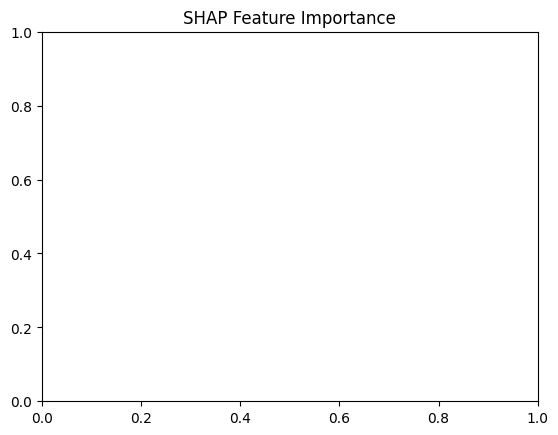

In [13]:
# SHAP Values for XGBoost
import shap

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)
plt.title("SHAP Feature Importance")

print("Top 10 Important Features by SHAP:")
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Importance': abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)
print(shap_importance.head(10))

In [14]:
# Save best model
import pickle

# Save best model (Logistic Regression)
with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(lr_best, f)

# Save feature names
feature_names = list(X_train.columns)
with open("../models/feature_names_v2.pkl", "wb") as f:
    pickle.dump(feature_names, f)

print("Best model saved!")
print("Feature names saved!")
print("Model: Logistic Regression")
print("Accuracy: 80.91%")

Best model saved!
Feature names saved!
Model: Logistic Regression
Accuracy: 80.91%
